In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_s_curve

from Autoencoders import ConformalAutoencoder
from helper import load_optimizer_and_scheduler, save_optimizer_and_scheduler
from data import make_half_sphere

random_state = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
    
    def forward(self, x):
        return self.fc(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )
    
    def forward(self, z):
        return self.fc(z)

In [3]:
data, labels = make_half_sphere(n_samples=2000, noise=0.05, random_state=random_state)
data = torch.tensor(data, dtype=torch.float32).to(device)
val_data, val_labels = make_half_sphere(n_samples=1000, noise=0.05, random_state=random_state)
val_data = torch.tensor(val_data, dtype=torch.float32).to(device)

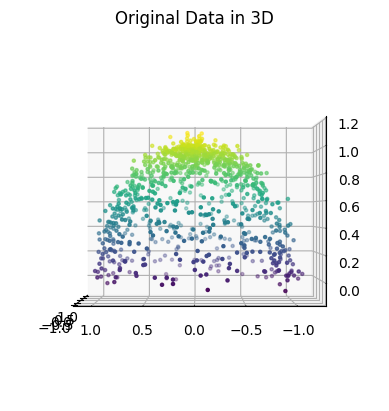

In [4]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0].cpu(), data[:, 1].cpu(), data[:, 2].cpu(), c=labels, s=5)
ax.set_title("Original Data in 3D")
ax.view_init(0, 180, 0)
plt.show()

In [24]:
# define model parameters
latent_dim = 2
input_dim = data.shape[1]
output_dim = data.shape[1]
batch_size = 64

train_dataloader = DataLoader(data, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

model_path = "models/conformal_autoencoder_cosine_half_sphere.pth"
optimizer_path = "models/conformal_autoencoder_cosine_half_sphere_optimizer.pth"

In [6]:
from metrics import conformality_cosine_loss

In [20]:
encoder = Encoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
decoder = Decoder(latent_dim=latent_dim, output_dim=output_dim).to(device)
conformal_autoencoder = ConformalAutoencoder(encoder, decoder, lambda_conf=0.5).to(device)
conformal_autoencoder.conformality_loss = conformality_cosine_loss
optmizer, scheduler = conformal_autoencoder.train_model(train_dataloader, val_dataloader, batch_size=batch_size, epochs=1000, learning_rate=0.001, log_every=100, val_every=100, scheduler_kwargs={"step_size": 100, "gamma": 0.5})

Epoch [100/1000], Loss: 0.00231506, Reconstruction Loss: 0.00111926, Conformal Loss: 0.00239161
Epoch [100/1000], Validation Loss: 0.00225239, Reconstruction Loss: 0.00103904, Conformal Loss: 0.00242669
Epoch [200/1000], Loss: 0.00203389, Reconstruction Loss: 0.00103632, Conformal Loss: 0.00199513
Epoch [200/1000], Validation Loss: 0.00215228, Reconstruction Loss: 0.00102316, Conformal Loss: 0.00225823
Epoch [300/1000], Loss: 0.00200825, Reconstruction Loss: 0.00100597, Conformal Loss: 0.00200456
Epoch [300/1000], Validation Loss: 0.00221513, Reconstruction Loss: 0.00099803, Conformal Loss: 0.00243420
Epoch [400/1000], Loss: 0.00190450, Reconstruction Loss: 0.00099163, Conformal Loss: 0.00182575
Epoch [400/1000], Validation Loss: 0.00202965, Reconstruction Loss: 0.00098749, Conformal Loss: 0.00208433
Epoch [500/1000], Loss: 0.00185269, Reconstruction Loss: 0.00096861, Conformal Loss: 0.00176816
Epoch [500/1000], Validation Loss: 0.00209112, Reconstruction Loss: 0.00096673, Conformal Lo

In [25]:
conformal_autoencoder.save_checkpoint(model_path)
save_optimizer_and_scheduler(optimizer_path, optmizer, scheduler)

Checkpoint saved to models/conformal_autoencoder_cosine_half_sphere.pth at epoch 1001
Optimizer and scheduler saved to models/conformal_autoencoder_cosine_half_sphere_optimizer.pth


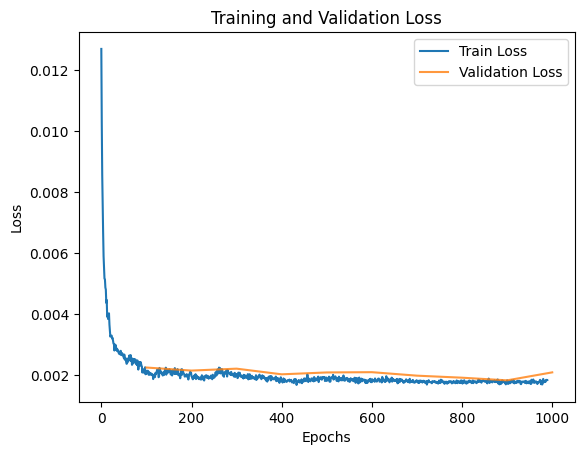

In [21]:
plt.plot(conformal_autoencoder.loss_list[10:], label='Train Loss')
plt.plot(np.linspace(100, 1000, 10), conformal_autoencoder.val_loss_list, alpha=0.8, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

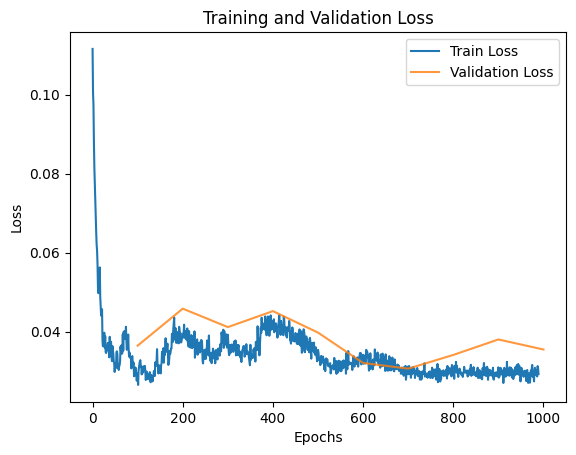

In [9]:
plt.plot(conformal_autoencoder.loss_list[10:], label='Train Loss')
plt.plot(np.linspace(100, 1000, 10), conformal_autoencoder.val_loss_list, alpha=0.8, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

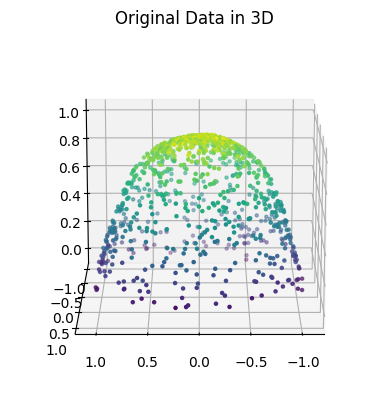

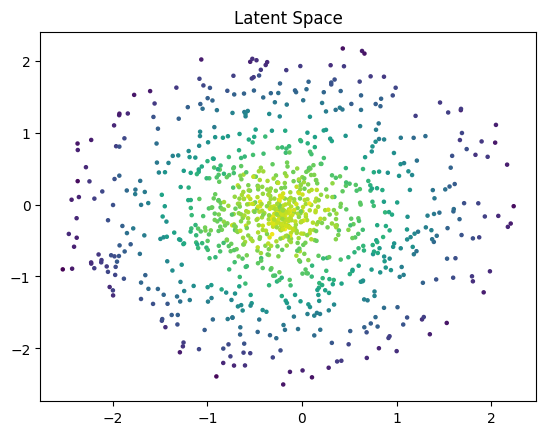

In [28]:
#Encode the data
encoded_data = conformal_autoencoder.encode(data)
# Decode the data
decoded_data = conformal_autoencoder.decode(encoded_data).cpu().detach()
encoded_data = encoded_data.cpu().detach()

# Visualize the reconstruction
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(decoded_data[:, 0], decoded_data[:, 1], decoded_data[:, 2], c=labels, cmap='viridis', s=5)
ax.set_title("Original Data in 3D")
ax.view_init(15, 90, 0)
plt.show()
# Visualize the latent space
plt.scatter(encoded_data[:, 0], encoded_data[:, 1], c=labels, cmap='viridis', s=5)
plt.title("Latent Space")
plt.show()

In [29]:
from torch.func import functional_call, jacrev, vmap

def gini(w: torch.Tensor) -> torch.Tensor:
    r"""The Gini coefficient from the `"Improving Molecular Graph Neural
    Network Explainability with Orthonormalization and Induced Sparsity"
    <https://arxiv.org/abs/2105.04854>`_ paper.

    Computes a regularization penalty :math:`\in [0, 1]` for each row of a
    matrix according to

    .. math::
        \mathcal{L}_\textrm{Gini}^i = \sum_j^n \sum_{j'}^n \frac{|w_{ij}
         - w_{ij'}|}{2 (n^2 - n)\bar{w_i}}

    and returns an average over all rows.

    Args:
        w (torch.Tensor): A two-dimensional tensor.
    """
    s = 0
    for row in w:
        t = row.repeat(row.size(0), 1)
        u = (t - t.T).abs().sum() / (2 * (row.size(-1)**2 - row.size(-1)) *
                                     row.abs().mean() + torch.finfo().eps)
        s += u
    s /= w.shape[0]
    return s

def get_batch_jacobian(func, inputs):
    params = dict(func.named_parameters())

    def fmodel(params, inputs):
        return functional_call(func, params, inputs)

    jacobians = vmap(jacrev(fmodel, argnums=(1)), in_dims=(None,0))(params, inputs)
    return jacobians

def evaluate_conformality(model, data):
    # still needs flattening for convolutions
    model.eval()
    with torch.no_grad():
        data_dim = data.shape[1]
        # latent samples
        latent = model.encode(data)
        latent_dim = latent.shape[1]

        # Compute the Jacobian of the decoder
        jacobians = get_batch_jacobian(model.decoder, latent)
        jTjs = torch.einsum('bji,bjk->bik', jacobians, jacobians)
        traces = vmap(torch.trace)(jTjs)
        lambda_factors = traces / latent.shape[1]

        # gini for diagonal elements
        diagonals = jTjs.diagonal(dim1=1, dim2=2)
        gini_value = gini(diagonals)

        # off diag mean, norm
        off_diagonal = jTjs - torch.diag_embed(diagonals)
        off_diag_mean = off_diagonal.abs().mean(dim=(1, 2))
        off_diag_norm = off_diagonal.norm(dim=(1, 2))
        off_diag_mean_normed = off_diag_mean / lambda_factors
        off_diag_norm_normed = off_diag_norm / lambda_factors

        # jTj - lambda*I mean, norm
        eye = torch.eye(jTjs.shape[1], device=jTjs.device).repeat(jTjs.shape[0], 1, 1)
        jTj_minus_lambdaI = jTjs - lambda_factors.unsqueeze(1).unsqueeze(2).repeat(1, jTjs.shape[1], jTjs.shape[1]) * eye
        jTj_minus_lambdaI_mean = jTj_minus_lambdaI.abs().mean(dim=(1, 2))
        jTj_minus_lambdaI_norm = jTj_minus_lambdaI.norm(dim=(1, 2))
        jTj_minus_lambdaI_mean_normed = jTj_minus_lambdaI_mean / lambda_factors
        jTj_minus_lambdaI_norm_normed = jTj_minus_lambdaI_norm / lambda_factors

        # determinant of jacobian vs sqrt lambda**m
        jacobian_determinants = torch.sqrt(torch.linalg.det(jTjs))
        determinant_vs_estimate = jacobian_determinants / (torch.sqrt(lambda_factors**latent_dim) + torch.finfo(torch.float32).eps)

        # std of latent space
        latent_std = latent.std(dim=0)
        
        return {
            'diagonal_gini': gini_value,
            'lambda_mean': lambda_factors.mean(),
            'lambda_std': lambda_factors.std(),
            'lambda_std_normed': lambda_factors.std() /lambda_factors.mean(),
            'off_diag_mean': off_diag_mean.mean(),
            'off_diag_norm': off_diag_norm.mean(),
            'off_diag_mean_normed': off_diag_mean_normed.mean(),
            'off_diag_norm_normed': off_diag_norm_normed.mean(),
            'jTj_minus_lambdaI_mean': jTj_minus_lambdaI_mean.mean(),
            'jTj_minus_lambdaI_norm': jTj_minus_lambdaI_norm.mean(),
            'jTj_minus_lambdaI_mean_normed': jTj_minus_lambdaI_mean_normed.mean(),
            'jTj_minus_lambdaI_norm_normed': jTj_minus_lambdaI_norm_normed.mean(),
            'determinant_vs_estimate_mean': determinant_vs_estimate.mean(),
            'determinant_vs_estimate_std': determinant_vs_estimate.std(),
            'latent_std': latent_std.mean(),
            'latent_std_max': latent_std.max(),
            'latent_std_min': latent_std.min(),
            'latent_norm': latent.norm(),
        }

In [30]:
stats = evaluate_conformality(conformal_autoencoder, data)
print("Conformality Statistics:")
for key, value in stats.items():
    print(f"{key}: {value.item():.4f}")
print("Reconstruction Error:")
print(torch.nn.MSELoss()(data, conformal_autoencoder(data)).item())

Conformality Statistics:
diagonal_gini: 0.0296
lambda_mean: 0.4973
lambda_std: 0.1700
lambda_std_normed: 0.3419
off_diag_mean: 0.0060
off_diag_norm: 0.0170
off_diag_mean_normed: 0.0143
off_diag_norm_normed: 0.0405
jTj_minus_lambdaI_mean: 0.0121
jTj_minus_lambdaI_norm: 0.0270
jTj_minus_lambdaI_mean_normed: 0.0291
jTj_minus_lambdaI_norm_normed: 0.0645
determinant_vs_estimate_mean: 0.9983
determinant_vs_estimate_std: 0.0028
latent_std: 0.8661
latent_std_max: 0.8695
latent_std_min: 0.8628
latent_norm: 39.3484
Reconstruction Error:
0.0009617737377993762


In [27]:
num = 900
J = torch.zeros((num, 2, 2))
for i in range(num):
    latent = encoder(data[i:i+1])
    jac = torch.autograd.functional.jacobian(decoder, latent)
    jac = jac[0,:,0,:]
    J[i] = jac.T @ jac
print(J.mean(dim=0))
print(J.std(dim=0))

tensor([[4.9819e-01, 2.6580e-04],
        [2.6580e-04, 4.9828e-01]])
tensor([[0.1712, 0.0156],
        [0.0156, 0.1710]])


In [26]:
# Load the model and optimizer from checkpoint
encoder = Encoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
decoder = Decoder(latent_dim=latent_dim, output_dim=output_dim).to(device)
autoencoder = ConformalAutoencoder(encoder, decoder).load_model_from_checkpoint(model_path).to(device)
optimizer = autoencoder.get_default_optimizer()
scheduler = autoencoder.get_default_scheduler(optimizer)
optimizer, scheduler = load_optimizer_and_scheduler(optimizer_path, optimizer, scheduler)

Model and custom variables loaded from models/conformal_autoencoder_cosine_half_sphere.pth
Optimizer and scheduler loaded from models/conformal_autoencoder_cosine_half_sphere_optimizer.pth
